In [59]:
from logging import info

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nbclient.jsonutil import JPEG

df = pd.read_csv('C:/CSV/vgsales.csv')

#####Step 1 - Cleaning Data ######
df=df.drop_duplicates()


#renaming Columns
df=df.rename(columns={'NA_Sales': "North America Sales"
                      ,'Global_Sales': 'Global Sales'
                      ,'EU_Sales':'Europe Sales'
                      ,'Global_Sales' : 'Global Sales',
                       'JP_Sales': 'Japan Sales',
                        'Other_Sales': 'Other Sales',
                         'Platform': 'Gaming Platform'})
###Filling null value  values###
df['Publisher'] = df['Publisher'].fillna('Unknown')

# Remove N/A or NaN from Year column
df = df[df['Year'].notna()]
df = df[df['Year'] != 'N/A']

# Convert Year to integer
df['Year'] = df['Year'].astype(int)
#Remove Zero from Global Sales
df=df[df['Global Sales'] !=0 ]
#Remove Zero from other sales
df=df[df['Other Sales'] !=0 ]

# Calculate the average
NA_Avg = df['North America Sales'].mean()
EU_Avg = df['Europe Sales'].mean()
JP_Avg = df['Japan Sales'].mean()

# Replace 0 with the average value
df.loc[df['North America Sales'] == 0, 'North America Sales'] = NA_Avg
df.loc[df['Europe Sales'] == 0, 'Europe Sales'] = EU_Avg
df.loc[df['Japan Sales'] == 0, 'Japan Sales'] = JP_Avg

df



,Rank,Name,Gaming Platform,Year,Genre,Publisher,North America Sales,Europe Sales,Japan Sales,Other Sales,Global Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
15017,15020,Fishdom 2 Deluxe,PC,2010,Puzzle,Rondomedia,0.41,0.02,0.09,0.01,0.02
15141,15144,Invizimals: The Lost Kingdom,PS3,2013,Action,Sony Computer Entertainment,0.41,0.02,0.09,0.01,0.02
15202,15205,Tale of a Hero,PC,2010,Adventure,Daedalic,0.41,0.02,0.09,0.01,0.02
15233,15236,Dance! It's Your Stage,PS3,2011,Misc,DTP Entertainment,0.41,0.02,0.09,0.01,0.02


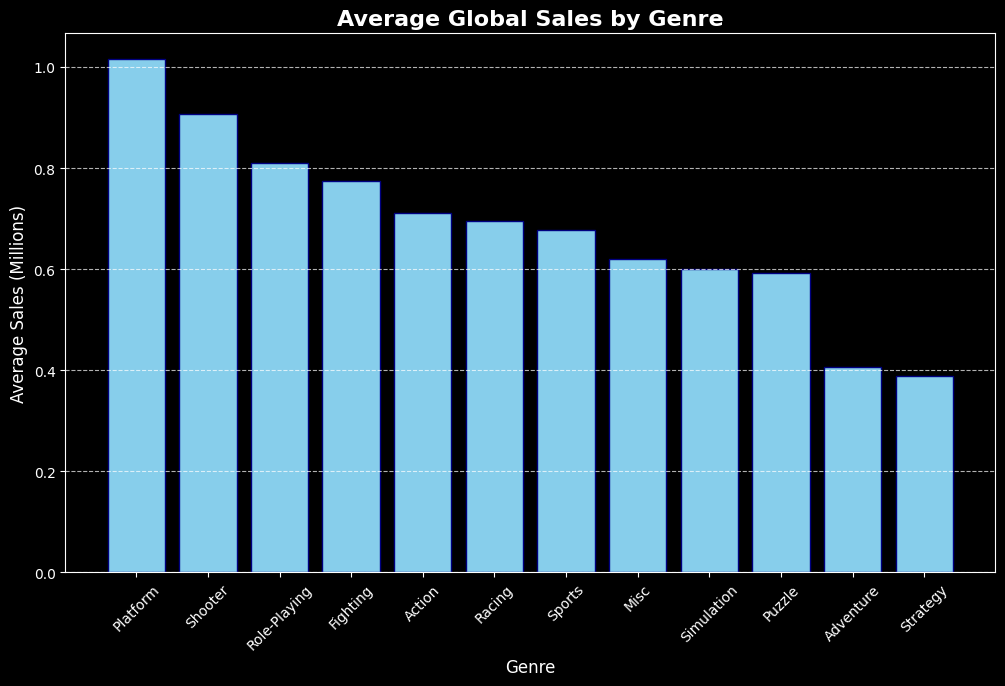

In [133]:
######Step-2 Data visualization #########


# Calculate Average Global Sales by Genre
avg_global_sales = df.groupby('Genre')['Global Sales'].mean().sort_values(ascending=False)


# Visualization using Matplotlib
plt.figure(figsize=(12, 7))


bars = plt.bar(avg_global_sales.index, avg_global_sales.values, color='skyblue', edgecolor='navy')
# Formatting the chart
plt.title('Average Global Sales by Genre', fontsize=16, fontweight='bold')
plt.xlabel('Genre', fontsize=12)
plt.ylabel('Average Sales (Millions)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)






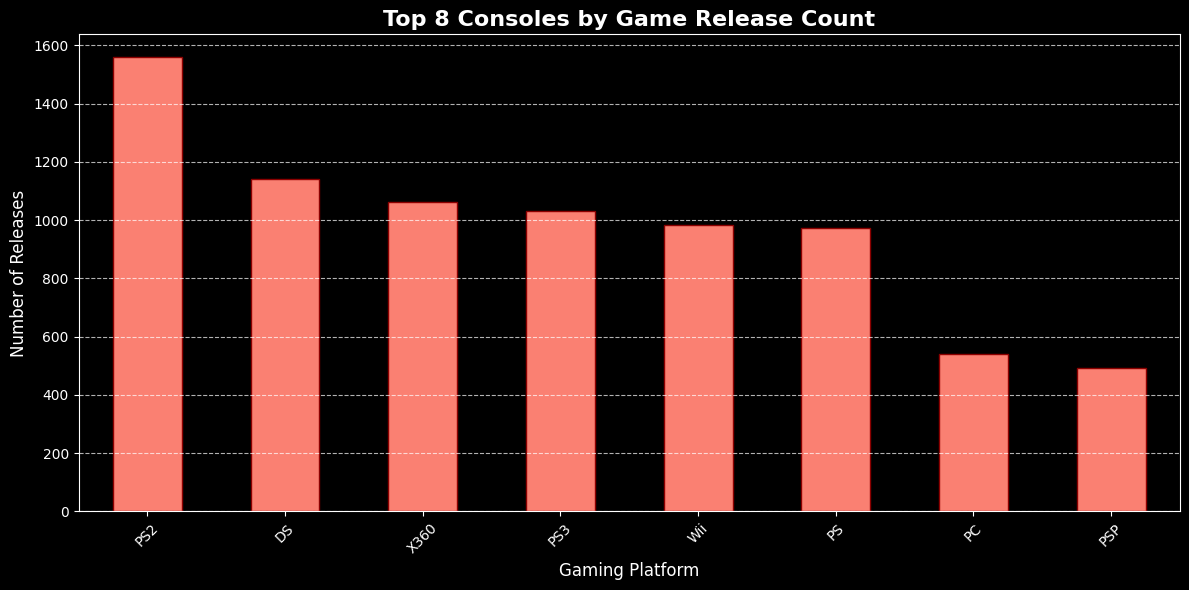

In [118]:
top_8_consoles = df['Gaming Platform'].value_counts().head(8)

#Drawing Bar chart

plt.figure(figsize=(12, 6))
top_8_consoles.plot(kind='bar', color='salmon', edgecolor='darkred')
plt.title('Top 8 Consoles by Game Release Count', fontsize=16, fontweight='bold')
plt.xlabel('Gaming Platform', fontsize=12)
plt.ylabel('Number of Releases', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


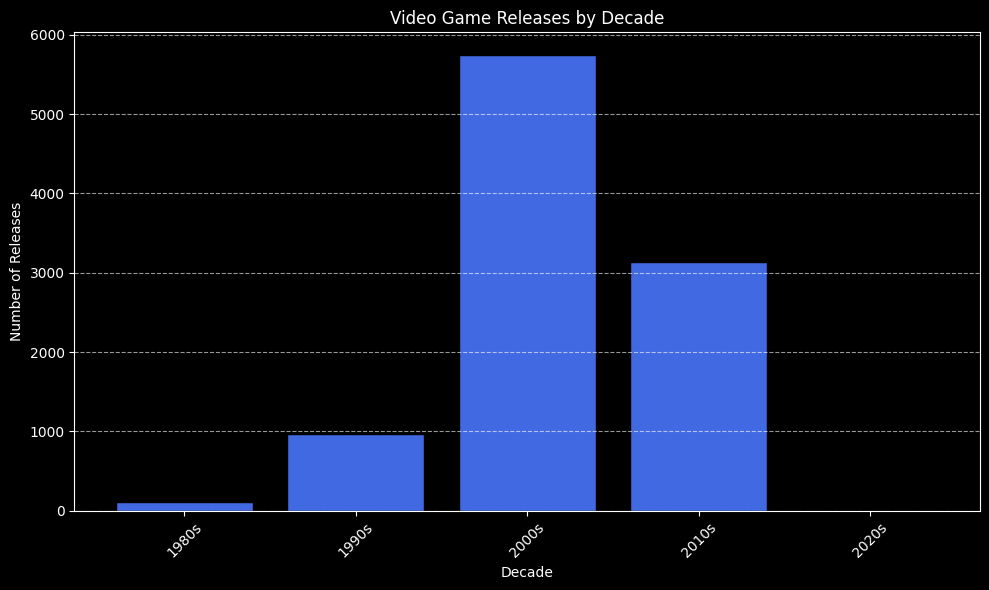

In [120]:
##### Which Decade got most releases####
# Convert Year to integer
df['Year'] = df['Year'].astype(float).astype(int)

# Create a Decade column
df['Decade'] = (df['Year'] // 10) * 10
df['Decade_Label'] = df['Decade'].astype(str) + 's'

# Count releases per decade
decade_counts = df.groupby('Decade_Label').size().sort_index()

# Visualization using Matplotlib
plt.figure(figsize=(10, 6))
plt.bar(decade_counts.index, decade_counts.values, color='royalblue', edgecolor='black')

# Drawing Bar chart
plt.title('Video Game Releases by Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Releases')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
